# GloFAS return periods : Somali region, Ethiopia

Fits return-period thresholds (RP2 to RP10) to GloFAS reanalysis discharge (v4, plus
v5 once its fetch lands) at the 8 monitoring points in / around Ethiopia's Somali
region, per season (annual | Gu | Kiremt | Deyr):

| set | stations | data |
|---|---|---|
| GloFAS official reporting points | Gode (G1904, Shabelle), Genale/Juba at Dolow, upper Genale | reanalysis 2003 to Jul 2026 + full ensemble reforecast 2003-2023 (Gu + Deyr months) |
| Ad-hoc grid points | station_1..4 (Shabelle), station_5 (Genale, Afder) | reanalysis 2003 to Jul 2026, reforecast control only complete |

Thresholds are fitted on the model's own annual and seasonal maxima (Gumbel + empirical),
so they are frequency-calibrated: this implicitly corrects GloFAS v4's magnitude bias
(in the Somalia comparison v4 ran 4-5x wet vs observed discharge on the same rivers;
v5 was near-unbiased but has no reforecast archive). Do not quote these thresholds
as real m3/s.

Outputs: `processed/glofas/glofas_return_periods.parquet` (thresholds per station |
season | RP | method) and an updated `processed/glofas/station_zone_mapping_all.csv`
on blob.

In [1]:
import os
import tempfile
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from scipy import stats
from shapely.geometry import Point

STAGE = "dev"
PROJECT_PREFIX = "ds-aa-eth-flooding"

RP_GRID = [2, 3, 4, 5, 7, 10]
# Kiremt (highland Jun-Sep rains) drives the annual discharge maxima at these
# stations, so Gu and Deyr floods need their own seasonal thresholds
SEASONS = {
    "annual": list(range(1, 13)),
    "gu": [3, 4, 5, 6],
    "kiremt": [7, 8, 9],
    "deyr": [10, 11, 12],
}

STATION_META = pd.DataFrame(
    [
        # station_id, label, river, zone pcode, zone name
        ("G1904", "Shabelle at Gode (G1904)", "Shabelle", "ET0506", "Shabelle"),
        ("station_1", "Shabelle upstream (43.03E 6.08N)", "Shabelle", "ET0506", "Shabelle"),
        ("station_2", "Shabelle mid (44.13E 5.63N)", "Shabelle", "ET0506", "Shabelle"),
        ("station_3", "Shabelle lower (44.53E 5.43N)", "Shabelle", "ET0506", "Shabelle"),
        ("station_4", "Shabelle at border (44.83E 5.13N)", "Shabelle", "ET0506", "Shabelle"),
        ("RP_4045_0535", "Genale upper (40.45E 5.35N)", "Genale", "ET0509", "Liban"),
        ("station_5", "Genale in Afder (42.08E 4.73N)", "Genale", "ET0508", "Afder"),
        ("RP_4205_0415", "Genale/Juba at Dolow", "Genale", "ET0509", "Liban"),
    ],
    columns=["station_id", "label", "river", "pcode", "zone"],
)
STATION_ORDER = STATION_META["station_id"].tolist()

## Load reanalysis discharge

v4: both master parquets (ad-hoc grid points + official reporting points), reanalysis
rows only, consolidated / intermediate deduped. v5: `glofas_discharge_v5.parquet`
(channel cells anchored to the v4 cells), loaded when the fetch has landed.

Both versions are fitted on 2003-2025 maxima: the common window keeps the versions
comparable, and the Somalia work found full-record fits over-fire in the modern
regime (nonstationarity).

In [2]:
RP_FIT_FROM, RP_FIT_TO = 2003, 2025

grid = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge.parquet", stage=STAGE
)
rp_pts = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_reporting_points.parquet", stage=STAGE
)
raw = pd.concat([grid, rp_pts], ignore_index=True)

rean = raw[raw["dataset"] == "reanalysis"].copy()
rean["valid_time"] = pd.to_datetime(rean["valid_time"]).dt.normalize()
# GloFAS stamps each 24h mean at the END of its period: shift back one day
rean["date"] = rean["valid_time"] - pd.Timedelta(days=1)
rean = (
    rean.sort_values(["valid_time", "product_type"])
    .drop_duplicates(["station_id", "date"], keep="last")
    .loc[:, ["station_id", "date", "discharge", "station_lon", "station_lat"]]
    .reset_index(drop=True)
)
rean["version"] = "v4_0"

try:
    v5 = stratus.load_parquet_from_blob(
        f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_v5.parquet", stage=STAGE
    )
    v5["valid_time"] = pd.to_datetime(v5["valid_time"]).dt.normalize()
    v5["date"] = v5["valid_time"] - pd.Timedelta(days=1)
    v5 = (
        v5.sort_values("valid_time")
        .drop_duplicates(["station_id", "date"], keep="last")
        .rename(columns={"longitude": "station_lon", "latitude": "station_lat"})
        .loc[:, ["station_id", "date", "discharge", "station_lon", "station_lat"]]
    )
    v5["version"] = "v5_0"
    rean = pd.concat([rean, v5], ignore_index=True)
    print("v5 reanalysis loaded")
except Exception as e:
    print(f"v5 reanalysis not available yet ({type(e).__name__}): fitting v4 only")

VERSIONS = sorted(rean["version"].unique())
DISPLAY_VERSION = VERSIONS[-1]  # newest version drives the charts
coords = rean.groupby("station_id")[["station_lon", "station_lat"]].first().reset_index()
stations = STATION_META.merge(coords, on="station_id")
print(rean.groupby(["version", "station_id"])["date"].agg(["min", "max", "size"]))

v5 reanalysis not available yet (ResourceNotFoundError): fitting v4 only
                            min        max  size
version station_id                              
v4_0    G1904        2003-01-01 2026-07-28  8608
        RP_4045_0535 2003-01-01 2026-07-28  8608
        RP_4205_0415 2003-01-01 2026-07-28  8608
        station_1    2003-01-01 2026-07-19  8601
        station_2    2003-01-01 2026-07-19  8601
        station_3    2003-01-01 2026-07-19  8601
        station_4    2003-01-01 2026-07-19  8601
        station_5    2003-01-01 2026-07-19  8601


## Station map

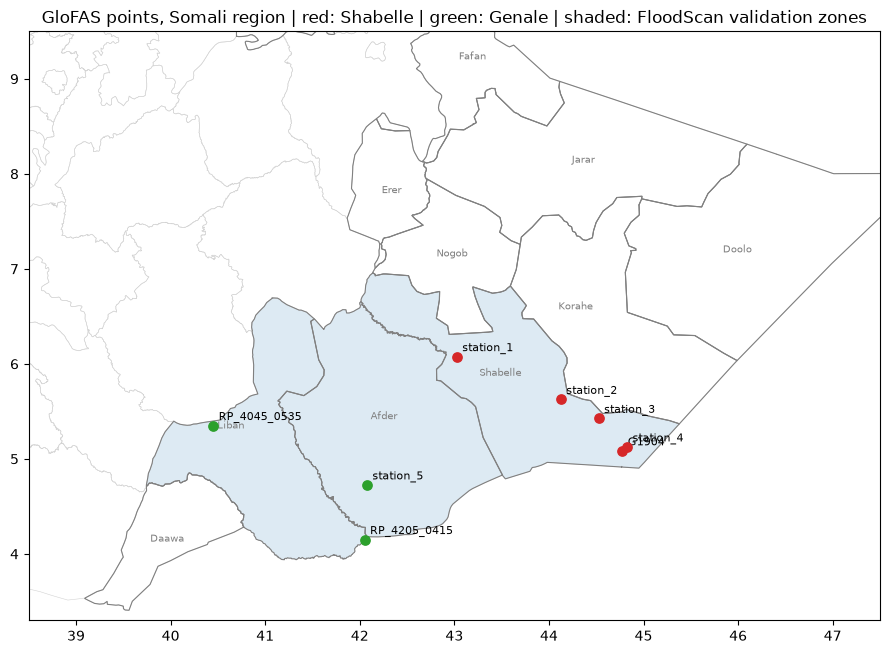

In [3]:
shp_bytes = stratus.load_blob_data("eth_shp.zip", stage=STAGE, container_name="polygon")
tmp = tempfile.mkdtemp()
zpath = os.path.join(tmp, "eth_shp.zip")
with open(zpath, "wb") as f:
    f.write(shp_bytes)
zipfile.ZipFile(zpath).extractall(tmp)
adm2 = gpd.read_file(os.path.join(tmp, "eth_adm2.shp"))
somali = adm2[adm2["ADM2_PCODE"].str.startswith("ET05")]

fig, ax = plt.subplots(figsize=(9, 7))
adm2.boundary.plot(ax=ax, color="lightgrey", linewidth=0.4)
somali.boundary.plot(ax=ax, color="grey", linewidth=0.8)
mapped = somali[somali["ADM2_PCODE"].isin(stations["pcode"].unique())]
mapped.plot(ax=ax, color="tab:blue", alpha=0.15)
for _, z in somali.iterrows():
    c = z.geometry.representative_point()
    ax.annotate(z["ADM2_EN"], (c.x, c.y), fontsize=7, color="grey", ha="center")
colors = {"Shabelle": "tab:red", "Genale": "tab:green"}
for _, st in stations.iterrows():
    ax.scatter(st["station_lon"], st["station_lat"], color=colors[st["river"]], s=45, zorder=5)
    ax.annotate(
        st["station_id"], (st["station_lon"], st["station_lat"]),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
ax.set_xlim(38.5, 47.5)
ax.set_ylim(3.3, 9.5)
ax.set_title("GloFAS points, Somali region | red: Shabelle | green: Genale | shaded: FloodScan validation zones")
plt.tight_layout()
plt.show()

## Daily discharge series

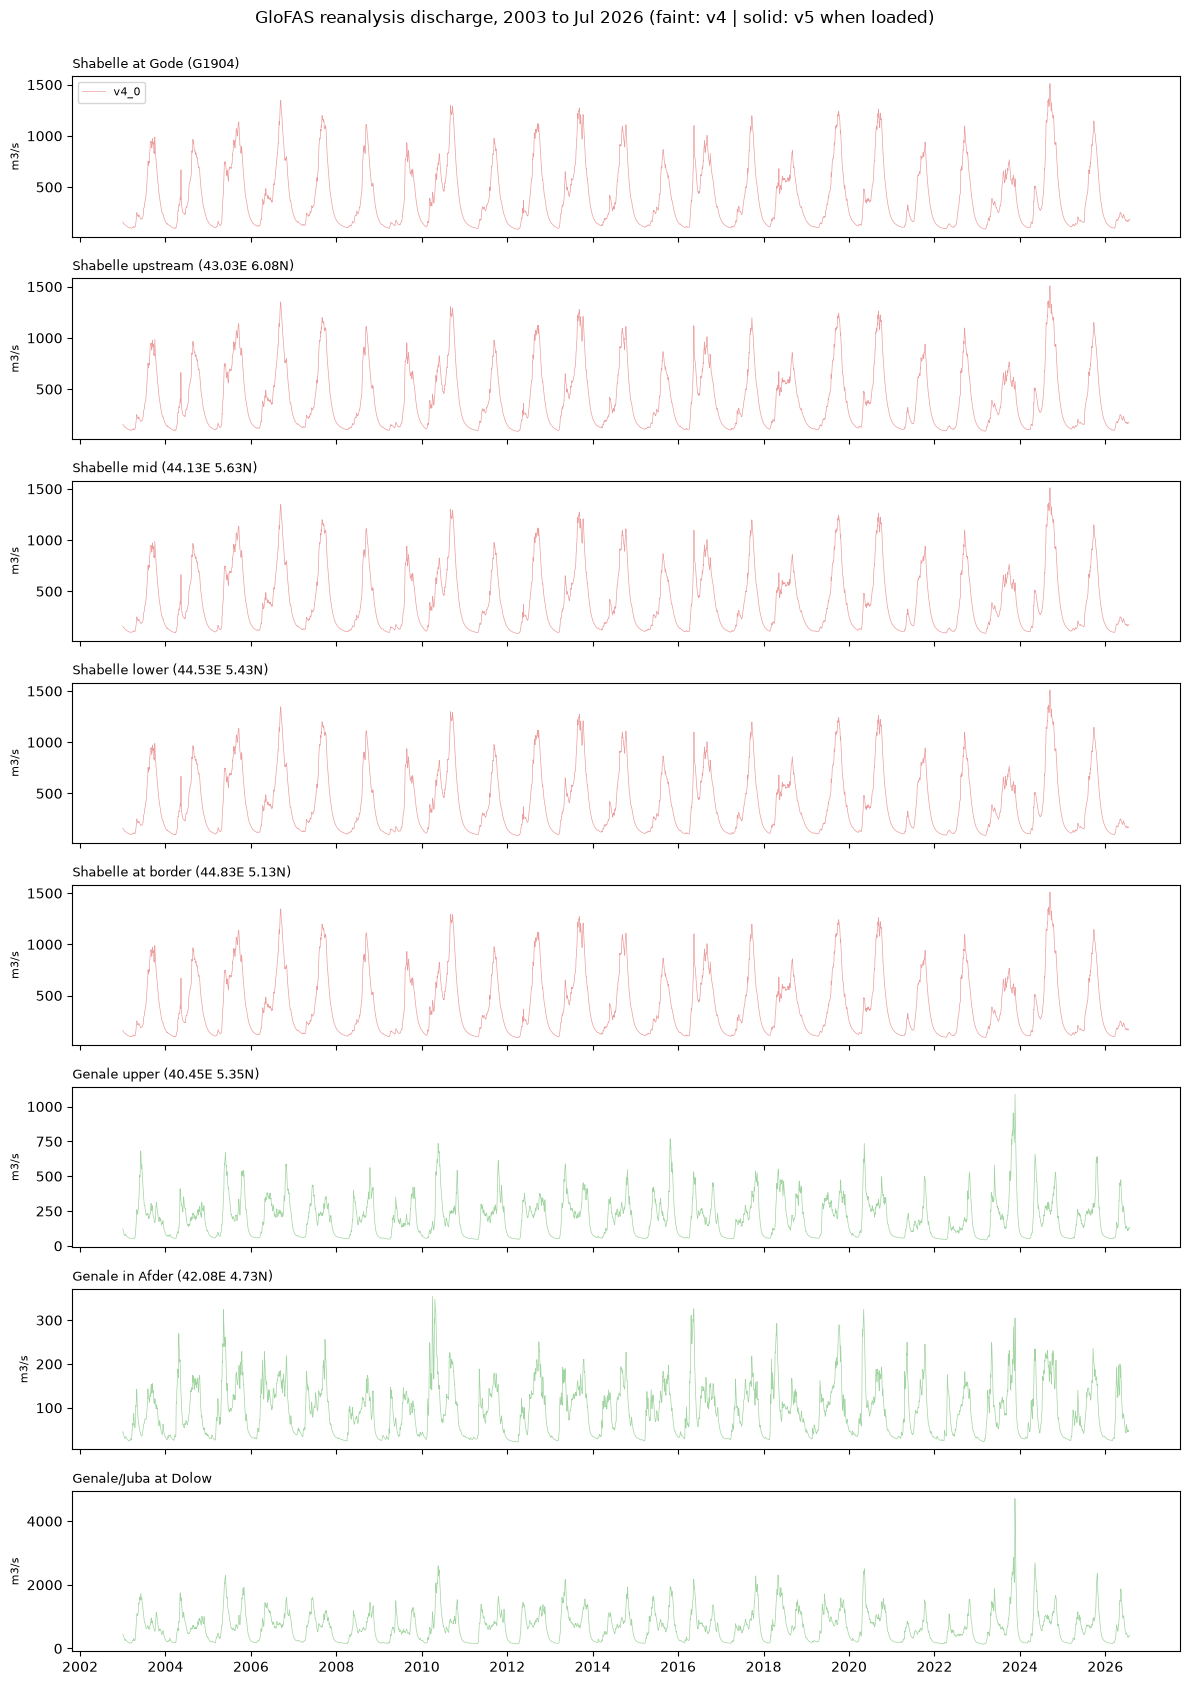

In [4]:
fig, axes = plt.subplots(len(STATION_ORDER), 1, figsize=(12, 2.1 * len(STATION_ORDER)), sharex=True)
for ax, sid in zip(axes, STATION_ORDER):
    meta = stations.set_index("station_id").loc[sid]
    for version, alpha in zip(VERSIONS, [0.45, 1.0]):
        sub = rean[(rean["station_id"] == sid) & (rean["version"] == version)]
        sub = sub[sub["date"] >= "2003-01-01"]
        ax.plot(sub["date"], sub["discharge"], linewidth=0.5,
                color=colors[meta["river"]], alpha=alpha, label=version)
    ax.set_ylabel("m3/s", fontsize=8)
    ax.set_title(meta["label"], fontsize=9, loc="left")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle("GloFAS reanalysis discharge, 2003 to Jul 2026 (faint: v4 | solid: v5 when loaded)", y=1.0)
plt.tight_layout()
plt.show()

## Seasonality

Monthly discharge climatology: Kiremt (Jul-Sep) dominates the annual maxima, while
FloodScan flooding in these zones clusters in Gu (Apr-May) and Deyr (Oct-Nov).
This is why seasonal thresholds are fitted alongside the annual ones.

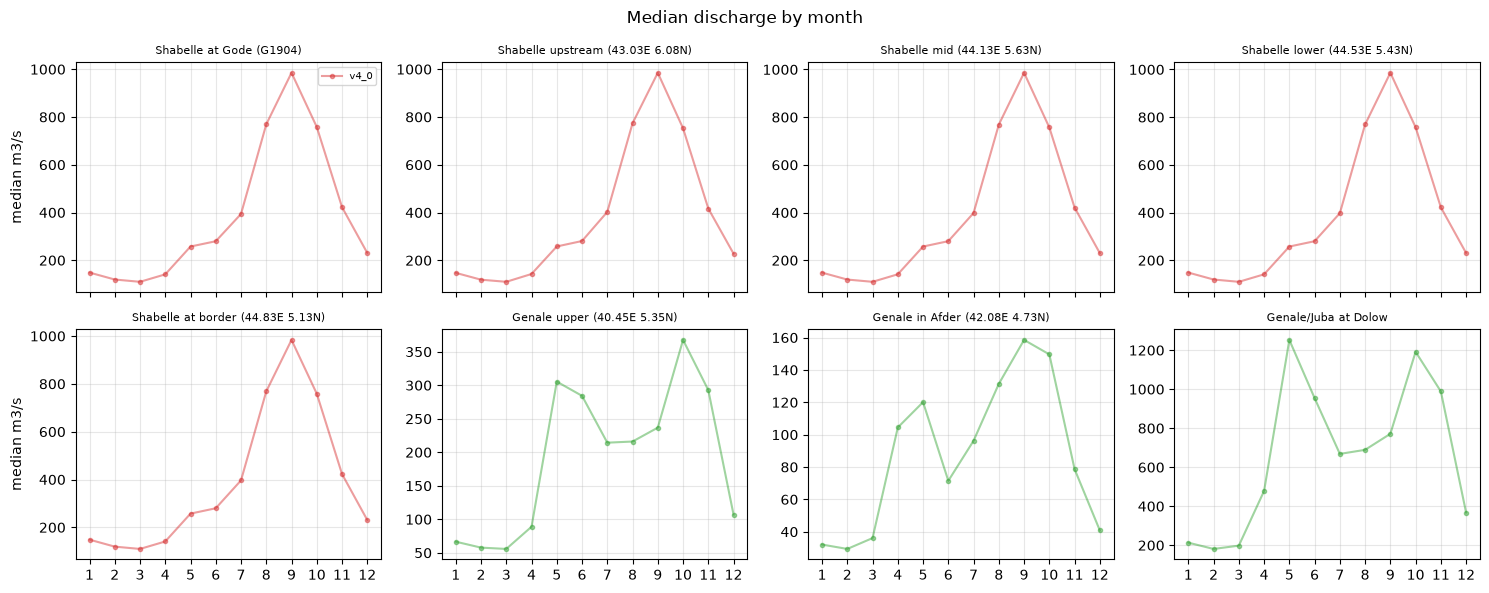

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for ax, sid in zip(axes.flat, STATION_ORDER):
    meta = stations.set_index("station_id").loc[sid]
    for version, alpha in zip(VERSIONS, [0.45, 1.0]):
        sub = rean[(rean["station_id"] == sid) & (rean["version"] == version)]
        clim = sub.groupby(sub["date"].dt.month)["discharge"].median()
        ax.plot(clim.index, clim.values, marker="o", markersize=3,
                color=colors[meta["river"]], alpha=alpha, label=version)
    ax.set_title(meta["label"], fontsize=8)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("median m3/s")
axes[1, 0].set_ylabel("median m3/s")
axes[0, 0].legend(fontsize=7)
plt.suptitle("Median discharge by month")
plt.tight_layout()
plt.show()

## Return-period fits

Block maxima per version | station | season (annual, Gu = Mar-Jun, Kiremt = Jul-Sep,
Deyr = Oct-Dec) on complete years 2003-2025. Gumbel fit via scipy MLE plus empirical
RPs from Weibull plotting positions.

In [6]:
def block_maxima(df: pd.DataFrame, months: list) -> pd.Series:
    sub = df[
        df["date"].dt.month.isin(months)
        & df["date"].dt.year.between(RP_FIT_FROM, RP_FIT_TO)
    ]
    return sub.groupby(sub["date"].dt.year)["discharge"].max()


def gumbel_threshold(maxima: pd.Series, rp: float) -> float:
    loc, scale = stats.gumbel_r.fit(maxima.values)
    return float(stats.gumbel_r.ppf(1 - 1 / rp, loc=loc, scale=scale))


def empirical_threshold(maxima: pd.Series, rp: float) -> float:
    # Weibull plotting positions: RP_i = (n + 1) / rank, rank 1 = largest
    x = np.sort(maxima.values)[::-1]
    n = len(x)
    rps = (n + 1) / np.arange(1, n + 1)
    if rp > rps[0]:
        return np.nan  # beyond the record: don't extrapolate empirically
    return float(np.interp(np.log(rp), np.log(rps[::-1]), x[::-1]))


rows = []
for version in VERSIONS:
    for sid in STATION_ORDER:
        sub = rean[(rean["station_id"] == sid) & (rean["version"] == version)]
        for season, months in SEASONS.items():
            maxima = block_maxima(sub, months)
            for rp in RP_GRID:
                rows.append({
                    "version": version, "station_id": sid, "season": season, "rp": rp,
                    "threshold_gumbel": gumbel_threshold(maxima, rp),
                    "threshold_empirical": empirical_threshold(maxima, rp),
                    "n_years": len(maxima),
                })
thresholds = pd.DataFrame(rows)
thresholds.pivot_table(index=["version", "station_id", "season"], columns="rp", values="threshold_gumbel").round(0)

rp                               2       3       4       5       7       10
version station_id   season                                                
v4_0    G1904        annual  1080.0  1167.0  1222.0  1264.0  1323.0  1385.0
                     deyr     930.0  1031.0  1096.0  1144.0  1214.0  1286.0
                     gu       410.0   499.0   556.0   598.0   659.0   722.0
                     kiremt  1067.0  1156.0  1213.0  1255.0  1317.0  1380.0
        RP_4045_0535 annual   570.0   630.0   668.0   696.0   738.0   780.0
                     deyr     502.0   563.0   602.0   631.0   673.0   716.0
                     gu       426.0   502.0   551.0   587.0   640.0   694.0
                     kiremt   310.0   335.0   351.0   363.0   381.0   399.0
        RP_4205_0415 annual  1950.0  2164.0  2301.0  2403.0  2551.0  2703.0
                     deyr    1620.0  1813.0  1937.0  2028.0  2161.0  2299.0
                     gu      1609.0  1865.0  2029.0  2150.0  2326.0  2508.0
                     kiremt   949.0  1017.0  1061.0  1094.0  1141.0  1189.0
        station_1    annual  1083.0  1170.0  1226.0  1268.0  1328.0  1390.0
                     deyr     929.0  1030.0  1095.0  1143.0  1214.0  1286.0
                     gu       411.0   500.0   557.0   599.0   660.0   723.0
                     kiremt  1070.0  1159.0  1216.0  1258.0  1320.0  1383.0
        station_2    annual  1081.0  1167.0  1223.0  1264.0  1324.0  1385.0
                     deyr     930.0  1031.0  1096.0  1144.0  1214.0  1286.0
                     gu       410.0   499.0   556.0   598.0   659.0   722.0
                     kiremt  1067.0  1157.0  1214.0  1256.0  1318.0  1381.0
        station_3    annual  1080.0  1167.0  1223.0  1264.0  1324.0  1385.0
                     deyr     930.0  1031.0  1096.0  1144.0  1214.0  1286.0
                     gu       410.0   499.0   556.0   598.0   659.0   722.0
                     kiremt  1067.0  1156.0  1213.0  1256.0  1317.0  1380.0
        station_4    annual  1080.0  1167.0  1222.0  1263.0  1323.0  1385.0
                     deyr     930.0  1032.0  1097.0  1145.0  1215.0  1287.0
                     gu       410.0   499.0   556.0   598.0   659.0   722.0
                     kiremt  1066.0  1156.0  1213.0  1255.0  1317.0  1380.0
        station_5    annual   236.0   264.0   281.0   294.0   313.0   332.0
                     deyr     189.0   212.0   226.0   236.0   252.0   267.0
                     gu       198.0   229.0   249.0   264.0   286.0   308.0
                     kiremt   193.0   206.0   215.0   221.0   231.0   240.0

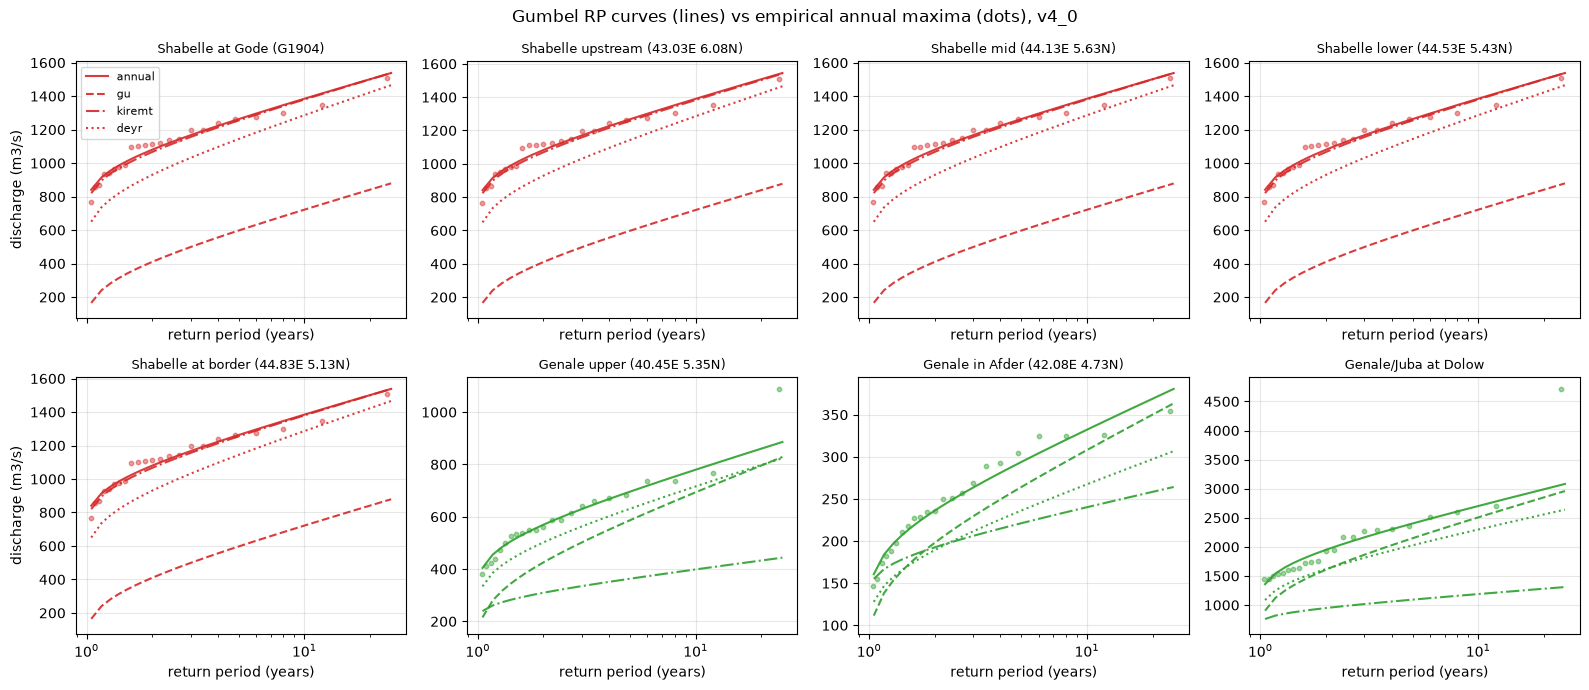

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, sid in zip(axes.flat, STATION_ORDER):
    sub = rean[(rean["station_id"] == sid) & (rean["version"] == DISPLAY_VERSION)]
    meta = stations.set_index("station_id").loc[sid]
    for season, style in [("annual", "-"), ("gu", "--"), ("kiremt", "-."), ("deyr", ":")]:
        maxima = block_maxima(sub, SEASONS[season])
        x = np.sort(maxima.values)[::-1]
        emp_rp = (len(x) + 1) / np.arange(1, len(x) + 1)
        loc, scale = stats.gumbel_r.fit(maxima.values)
        rp_line = np.linspace(1.05, 25, 200)
        ax.plot(rp_line, stats.gumbel_r.ppf(1 - 1 / rp_line, loc=loc, scale=scale),
                style, color=colors[meta["river"]], label=season, alpha=0.9)
        ax.scatter(emp_rp, x, s=10, color=colors[meta["river"]],
                   alpha=0.45 if season == "annual" else 0.0)
    ax.set_xscale("log")
    ax.set_title(meta["label"], fontsize=9)
    ax.set_xlabel("return period (years)")
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("discharge (m3/s)")
axes[1, 0].set_ylabel("discharge (m3/s)")
axes[0, 0].legend(fontsize=8)
plt.suptitle(f"Gumbel RP curves (lines) vs empirical annual maxima (dots), {DISPLAY_VERSION}")
plt.tight_layout()
plt.show()

## Threshold exceedances in the record

Sanity check on the RP3 Gumbel thresholds (annual + seasonal): which years cross
them, and does the count match the nominal frequency.

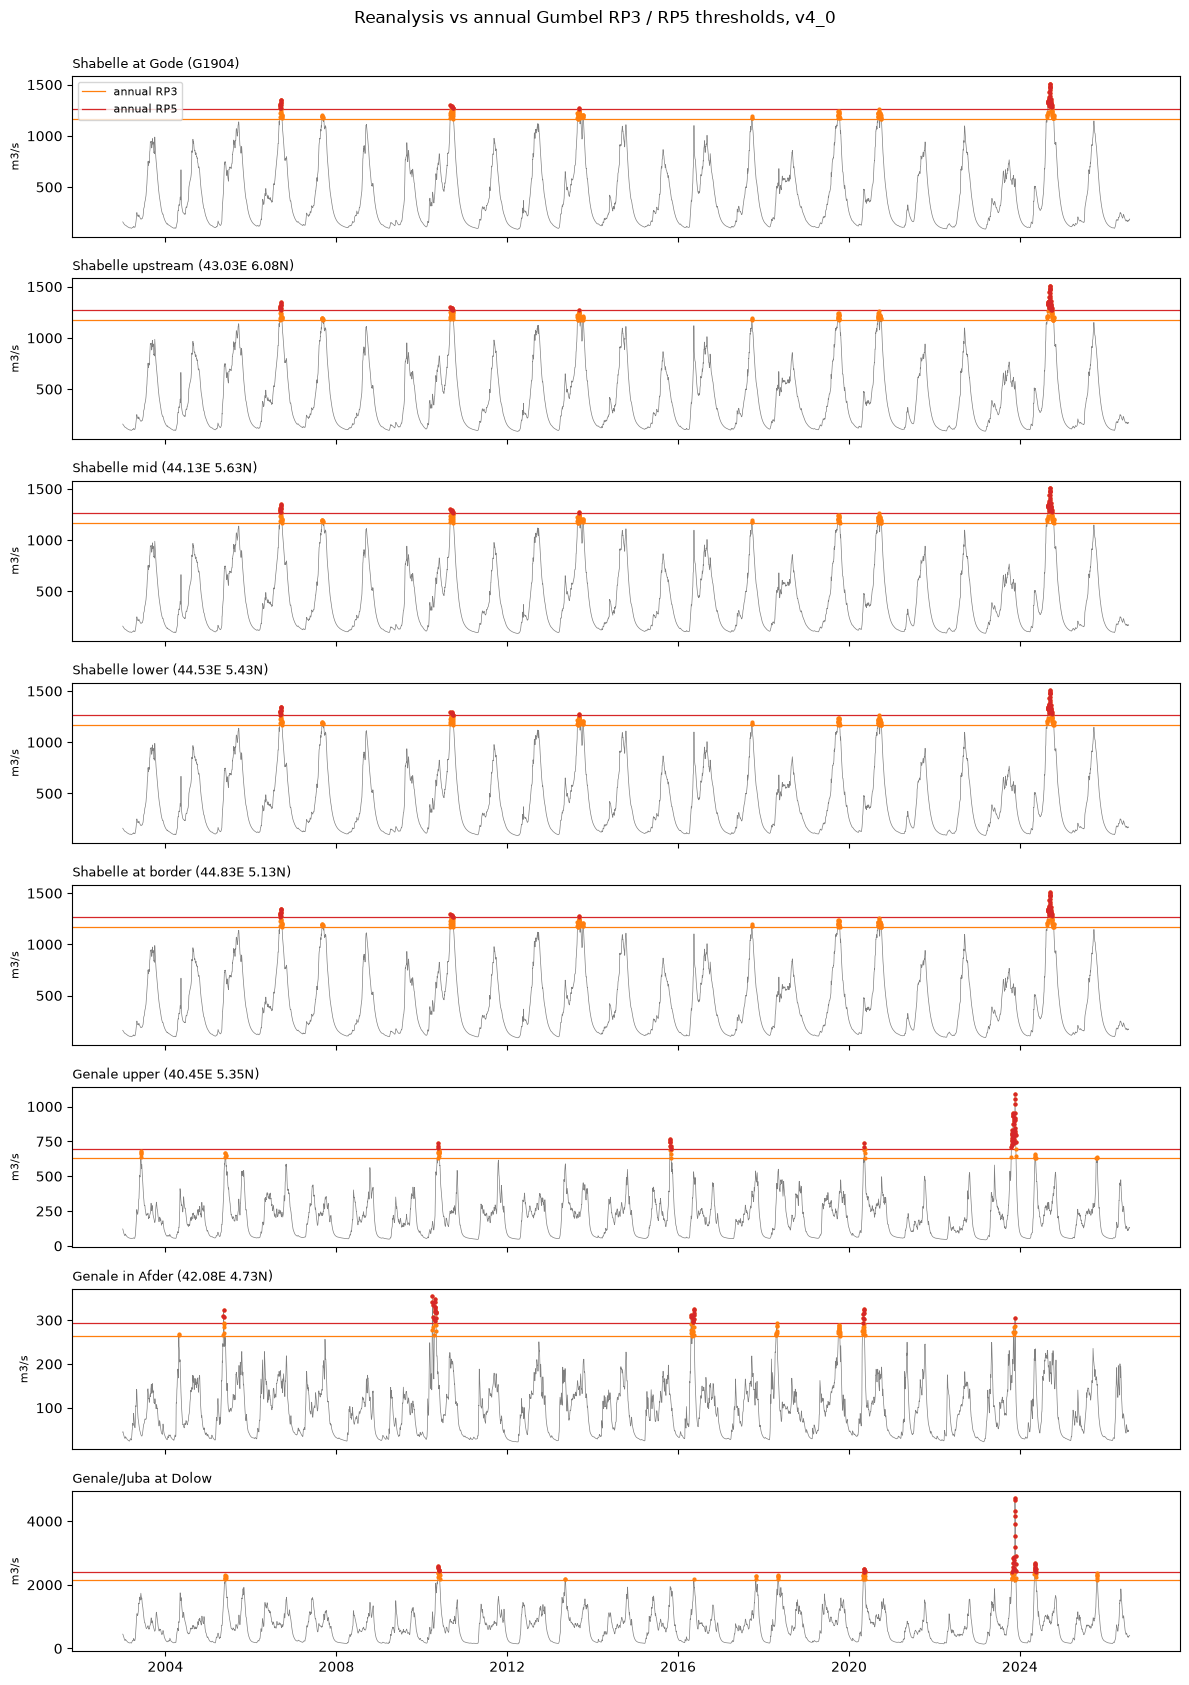

,station_id,season,n_years_over_rp3,expected,years
0,G1904,annual,8,7.7,"2006, 2007, 2010, 2013, 2017, 2019, 2020, 2024"
1,G1904,gu,7,7.7,"2004, 2005, 2010, 2013, 2016, 2018, 2024"
2,G1904,deyr,10,7.7,"2006, 2007, 2010, 2013, 2014, 2017, 2019, 2020..."
3,station_1,annual,8,7.7,"2006, 2007, 2010, 2013, 2017, 2019, 2020, 2024"
4,station_1,gu,7,7.7,"2004, 2005, 2010, 2013, 2016, 2018, 2024"
5,station_1,deyr,10,7.7,"2006, 2007, 2010, 2013, 2014, 2017, 2019, 2020..."
6,station_2,annual,8,7.7,"2006, 2007, 2010, 2013, 2017, 2019, 2020, 2024"
7,station_2,gu,7,7.7,"2004, 2005, 2010, 2013, 2016, 2018, 2024"
8,station_2,deyr,10,7.7,"2006, 2007, 2010, 2013, 2014, 2017, 2019, 2020..."
9,station_3,annual,8,7.7,"2006, 2007, 2010, 2013, 2017, 2019, 2020, 2024"


In [8]:
thr_disp = thresholds[thresholds["version"] == DISPLAY_VERSION].set_index(
    ["station_id", "season", "rp"]
)
fig, axes = plt.subplots(len(STATION_ORDER), 1, figsize=(12, 2.1 * len(STATION_ORDER)), sharex=True)
for ax, sid in zip(axes, STATION_ORDER):
    sub = rean[(rean["station_id"] == sid) & (rean["version"] == DISPLAY_VERSION)]
    meta = stations.set_index("station_id").loc[sid]
    ax.plot(sub["date"], sub["discharge"], linewidth=0.5, color="grey")
    for rp, c in [(3, "tab:orange"), (5, "tab:red")]:
        t = thr_disp.loc[(sid, "annual", rp), "threshold_gumbel"]
        ax.axhline(t, color=c, linewidth=0.9, label=f"annual RP{rp}")
        over = sub[sub["discharge"] >= t]
        ax.scatter(over["date"], over["discharge"], s=4, color=c, zorder=5)
    ax.set_title(meta["label"], fontsize=9, loc="left")
    ax.set_ylabel("m3/s", fontsize=8)
axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle(f"Reanalysis vs annual Gumbel RP3 / RP5 thresholds, {DISPLAY_VERSION}", y=1.0)
plt.tight_layout()
plt.show()

years_over = []
for sid in STATION_ORDER:
    sub = rean[(rean["station_id"] == sid) & (rean["version"] == DISPLAY_VERSION)]
    for season in ["annual", "gu", "deyr"]:
        am = block_maxima(sub, SEASONS[season])
        t = thr_disp.loc[(sid, season, 3), "threshold_gumbel"]
        years_over.append({
            "station_id": sid, "season": season,
            "n_years_over_rp3": int((am >= t).sum()),
            "expected": round(len(am) / 3, 1),
            "years": ", ".join(str(y) for y in am[am >= t].index),
        })
pd.DataFrame(years_over)

## Save outputs to blob

In [9]:
thresholds_out = thresholds.merge(STATION_META, on="station_id")
stratus.upload_parquet_to_blob(
    thresholds_out,
    f"{PROJECT_PREFIX}/processed/glofas/glofas_return_periods.parquet",
    stage=STAGE,
)
mapping_all = stations[["station_id", "label", "river", "station_lon", "station_lat", "pcode", "zone"]]
stratus.upload_csv_to_blob(
    mapping_all,
    f"{PROJECT_PREFIX}/processed/glofas/station_zone_mapping_all.csv",
    stage=STAGE,
)
print("saved:",
      f"{PROJECT_PREFIX}/processed/glofas/glofas_return_periods.parquet |",
      f"{PROJECT_PREFIX}/processed/glofas/station_zone_mapping_all.csv")

saved: ds-aa-eth-flooding/processed/glofas/glofas_return_periods.parquet | ds-aa-eth-flooding/processed/glofas/station_zone_mapping_all.csv
